# a) Imagine you are asking ChatGPT a question to generate a python program of the ID3 example of the theoretical lectures. What would be the question? Write it down. Look at the generated code, is the code ok? 

|  NO. |   RISK   | CREDIT HISTORY | DEBT | COLLATERAL |      INCOME |
| :--: | :------: | :------------: | :--: | :--------: | :---------: |
|   1  |     high |            bad | high |       none |  $0 to $15k |
|   2  |     high |        unknown | high |       none | $15 to $35k |
|   3  | moderate |        unknown |  low |       none | $15 to $35k |
|   4  |     high |        unknown |  low |       none |  $0 to $15k |
|   5  |      low |        unknown |  low |       none |   over $35k |
|   6  |      low |        unknown |  low |   adequate |   over $35k |
|   7  |     high |            bad |  low |       none |  $0 to $15k |
|   8  | moderate |            bad |  low |   adequate |   over $35k |
|   9  |      low |           good |  low |       none |   over $35k |
|  10  |      low |           good | high |   adequate |   over $35k |
|  11  |     high |           good | high |       none |  $0 to $15k |
|  12  | moderate |           good | high |       none | $15 to $35k |
|  13  |      low |           good | high |       none |   over $35k |
|  14  |     high |            bad | high |       none | $15 to $35k |

The question would be: Can you implement the ID3 algorithm in Python and apply it to the following dataset of loan risk classification, where the target attribute is RISK? Please also generate a graphical visualization of the final decision tree using matplotlib (not just the dictionary output). The dataset is: [insert table]

The CHATGPT code is here:

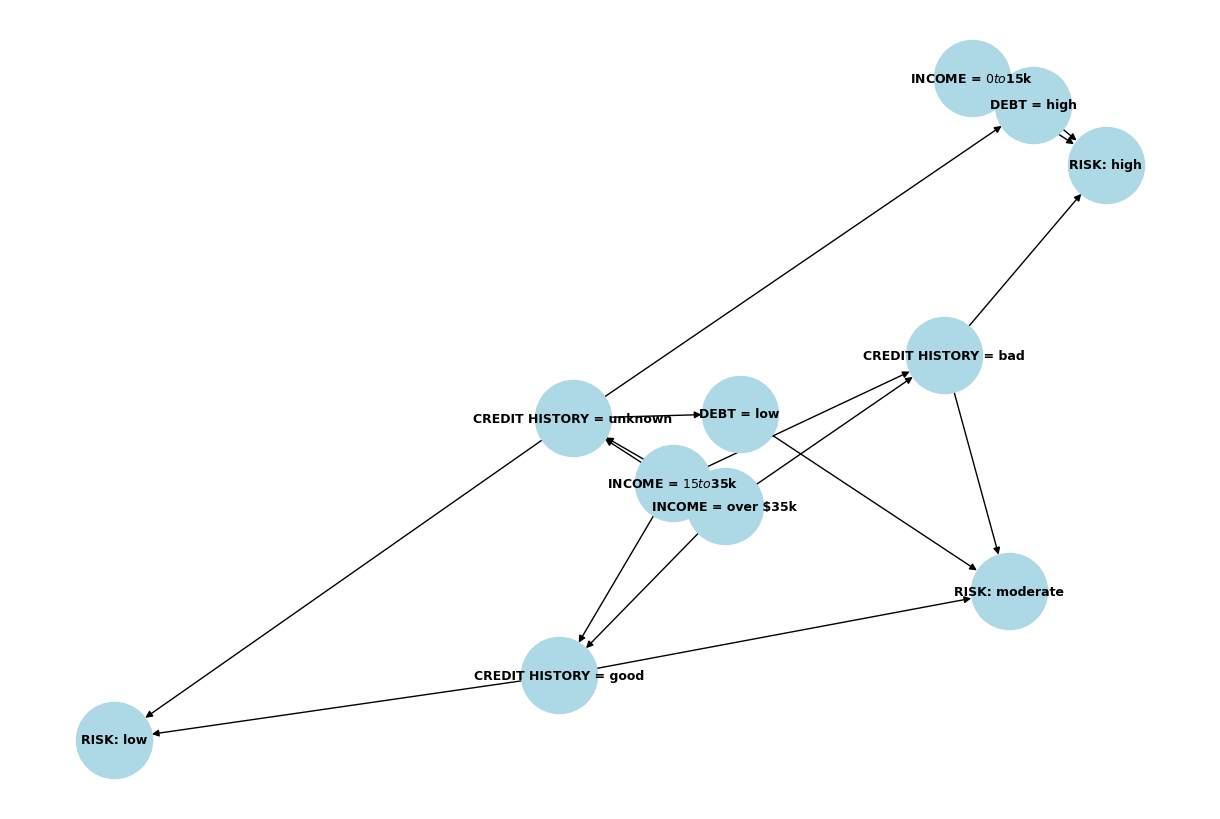

In [5]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# ------------------------
# 1. Dataset
# ------------------------
data = [
    [1,  "high",      "bad",       "high", "none",     "$0 to $15k"],
    [2,  "high",      "unknown",   "high", "none",     "$15 to $35k"],
    [3,  "moderate",  "unknown",   "low",  "none",     "$15 to $35k"],
    [4,  "high",      "unknown",   "low",  "none",     "$0 to $15k"],
    [5,  "low",       "unknown",   "low",  "none",     "over $35k"],
    [6,  "low",       "unknown",   "low",  "adequate", "over $35k"],
    [7,  "high",      "bad",       "low",  "none",     "$0 to $15k"],
    [8,  "moderate",  "bad",       "low",  "adequate", "over $35k"],
    [9,  "low",       "good",      "low",  "none",     "over $35k"],
    [10, "low",       "good",      "high", "adequate", "over $35k"],
    [11, "high",      "good",      "high", "none",     "$0 to $15k"],
    [12, "moderate",  "good",      "high", "none",     "$15 to $35k"],
    [13, "low",       "good",      "high", "none",     "over $35k"],
    [14, "high",      "bad",       "high", "none",     "$15 to $35k"]
]

cols = ["NO", "RISK", "CREDIT HISTORY", "DEBT", "COLLATERAL", "INCOME"]
df = pd.DataFrame(data, columns=cols)

# ------------------------
# 2. Entropy & Info Gain
# ------------------------
def entropy(column):
    values, counts = zip(*column.value_counts().items())
    total = sum(counts)
    return -sum((c/total) * math.log2(c/total) for c in counts)

def info_gain(df, attr, target):
    total_entropy = entropy(df[target])
    values = df[attr].unique()
    weighted_entropy = 0
    for v in values:
        subset = df[df[attr] == v]
        weighted_entropy += (len(subset)/len(df)) * entropy(subset[target])
    return total_entropy - weighted_entropy

# ------------------------
# 3. ID3 Algorithm
# ------------------------
def id3(df, target, features):
    # if all same class -> return leaf
    if len(df[target].unique()) == 1:
        return df[target].iloc[0]
    # if no features left -> return majority class
    if not features:
        return df[target].mode()[0]
    # choose best feature
    gains = {f: info_gain(df, f, target) for f in features}
    best = max(gains, key=gains.get)
    tree = {best: {}}
    for v in df[best].unique():
        subset = df[df[best] == v]
        if subset.empty:
            tree[best][v] = df[target].mode()[0]
        else:
            new_features = [f for f in features if f != best]
            tree[best][v] = id3(subset, target, new_features)
    return tree

features = ["CREDIT HISTORY", "DEBT", "COLLATERAL", "INCOME"]
tree = id3(df, "RISK", features)

# ------------------------
# 4. Tree Visualization
# ------------------------
def draw_tree(tree, parent=None, graph=None):
    if graph is None:
        graph = nx.DiGraph()
    for attr, branches in tree.items():
        for val, sub in branches.items():
            node = f"{attr} = {val}"
            graph.add_node(node)
            if parent:
                graph.add_edge(parent, node)
            if isinstance(sub, dict):
                draw_tree(sub, parent=node, graph=graph)
            else:
                leaf = f"RISK: {sub}"
                graph.add_node(leaf)
                graph.add_edge(node, leaf)
    return graph

graph = draw_tree(tree)
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(graph, seed=42)
nx.draw(graph, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=9, font_weight="bold")
plt.show()


The code ....

# b) Draw both decision trees, with and without stratify  (you can copy the drawing into your document). What is the main difference? only one/two sentence/s.

Decision trees -> [here](../../../HM1_DT_25.ipynb)

With stratify=y, the class distribution in the training set is preserved, leading to more balanced splits. Without stratification, the training set becomes unbalanced, so the decision tree structure changes accordingly. That's why with stratify the inital values are [6,7,4] and without stratify they are [3,10,4].

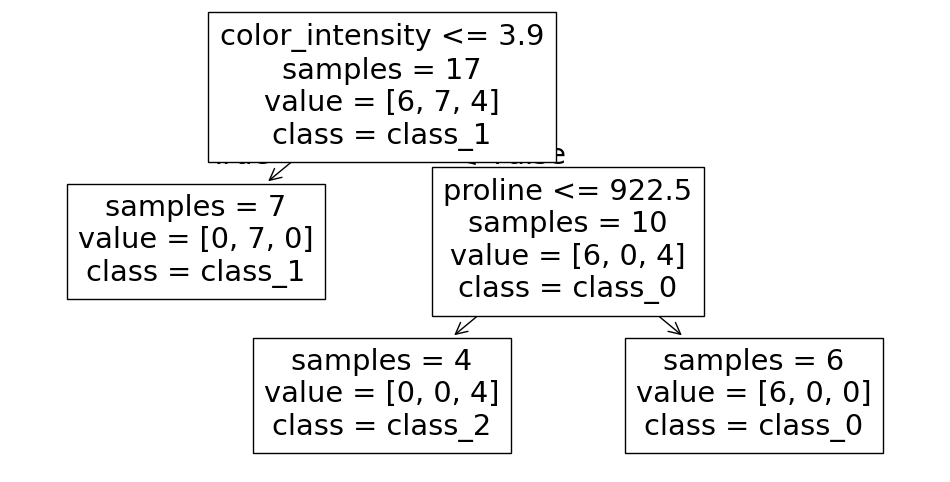
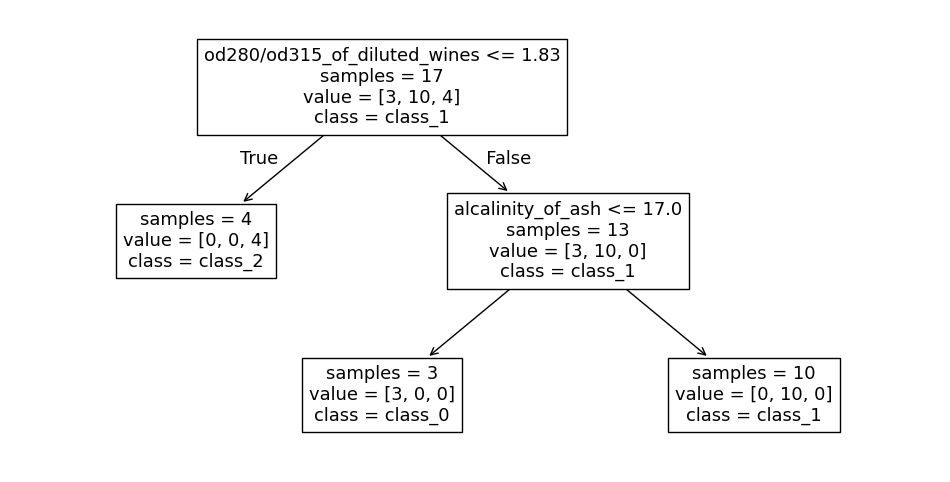

# c) Why is now the accuracy lower? Please write only one/two sentence/s... Hint, look in the scikit-learn documentation for meaning of the command stratify=y.

Without stratification, the training set does not preserve the original class distribution, leading to a biased model that generalizes worse and thus lowers accuracy.